# EV Market Adoption Analysis

## Objective
Analyze electric vehicle data to understand adoption trends, top manufacturers, and geographic distribution.

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

In [67]:
df = pd.read_csv("../data/Electric_Vehicle_Population_Data.csv")
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,1N4AZ0CP6D,King,Kirkland,WA,98034.0,2013,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,75.0,1.0,154635729,POINT (-122.22901 47.72201),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
1,5YJ3E1EC8L,Kitsap,Bainbridge Island,WA,98110.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,308.0,23.0,107518645,POINT (-122.521 47.62759),PUGET SOUND ENERGY INC,5.303509e+10
2,5YJ3E1EBXJ,King,Seattle,WA,98144.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,37.0,474808813,POINT (-122.30866 47.57874),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,ZFAFFAC45R,Thurston,Yelm,WA,98597.0,2024,FIAT,500E,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,2.0,273658514,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10
4,5YJYGDEE3L,King,Kent,WA,98030.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,47.0,109579900,POINT (-122.19975 47.37483),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10


## Data Loading and Cleaning
This section loads the dataset and prepares it for analysis by handling missing values and formatting column names.

In [68]:
# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Check missing values
df.isnull().sum()

vin (1-10)                                             0
county                                                12
city                                                  12
state                                                  0
postal code                                           12
model year                                             0
make                                                   0
model                                                  0
electric vehicle type                                  0
clean alternative fuel vehicle (cafv) eligibility      0
electric range                                        12
legislative district                                 703
dol vehicle id                                         0
vehicle location                                      20
electric utility                                      12
2020 census tract                                     12
dtype: int64

In [69]:
# Drop rows with missing values
df = df.dropna(subset=['county', 'city', 'electric range'])

# Check dataset size after cleaning
df.shape

(280809, 16)

In [70]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
Index: 280809 entries, 0 to 280832
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   vin (1-10)                                         280809 non-null  str    
 1   county                                             280809 non-null  str    
 2   city                                               280809 non-null  str    
 3   state                                              280809 non-null  str    
 4   postal code                                        280809 non-null  float64
 5   model year                                         280809 non-null  int64  
 6   make                                               280809 non-null  str    
 7   model                                              280809 non-null  str    
 8   electric vehicle type                              280809 non-null  str    
 9   clean alt

,postal code,model year,electric range,legislative district,dol vehicle id,2020 census tract
count,280809.000000,280809.000000,280809.000000,280118.000000,2.808090e+05,2.808090e+05
mean,98175.407131,2022.111588,38.756995,28.819330,2.470592e+08,5.297039e+10
std,2591.125061,3.064421,77.902716,14.907326,6.325495e+07,1.654881e+09
min,1030.000000,1999.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2021.000000,0.000000,17.000000,2.240723e+08,5.303301e+10
50%,98133.000000,2023.000000,0.000000,32.000000,2.642394e+08,5.303303e+10
75%,98382.000000,2024.000000,32.000000,42.000000,2.803000e+08,5.305394e+10
max,99517.000000,2027.000000,337.000000,49.000000,4.791150e+08,6.601095e+10


## Top EV Manufacturers
This analysis identifies the leading EV manufacturers based on number of registered vehicles.

In [71]:
top_makes = df['make'].value_counts().head(10)
top_makes

make
TESLA         114808
CHEVROLET      19410
NISSAN         16153
FORD           15422
KIA            14101
TOYOTA         11978
BMW            11647
HYUNDAI        10578
RIVIAN          8950
VOLKSWAGEN      7508
Name: count, dtype: int64

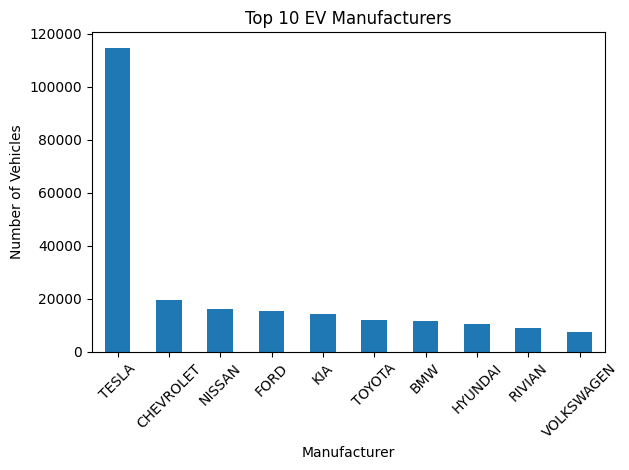

In [72]:
plt.figure()
top_makes.plot(kind='bar')
plt.title("Top 10 EV Manufacturers")
plt.xlabel("Manufacturer")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../visuals/charts/top_manufacturers.png")
plt.show()

## EV Adoption Over Time
This section examines how EV adoption has changed across years.

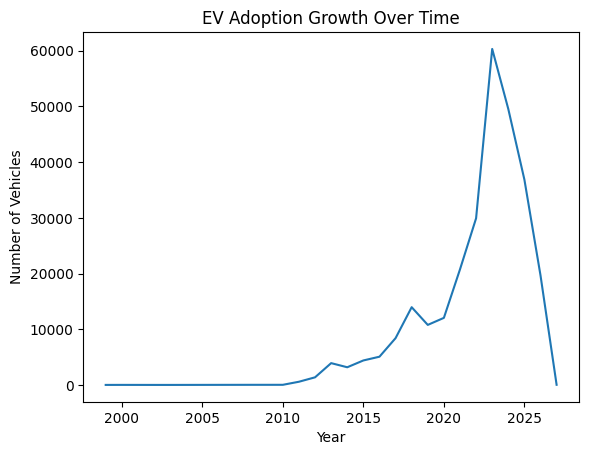

In [73]:
year_counts = df['model year'].value_counts().sort_index()

plt.figure()
year_counts.plot(kind='line')
plt.title("EV Adoption Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Vehicles")
plt.savefig("../visuals/charts/ev_growth.png")
plt.show()

## Geographic Distribution of EVs
This section analyzes which counties and cities have the highest EV adoption.

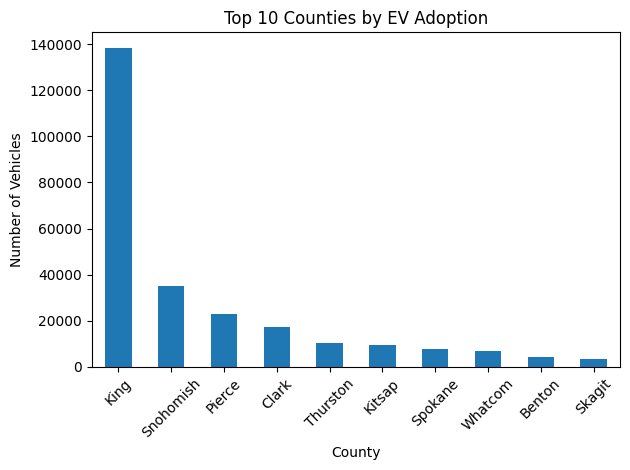

In [74]:
county_counts = df['county'].value_counts().head(10)

plt.figure()
county_counts.plot(kind='bar')
plt.title("Top 10 Counties by EV Adoption")
plt.xlabel("County")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../visuals/charts/top_counties.png")
plt.show()

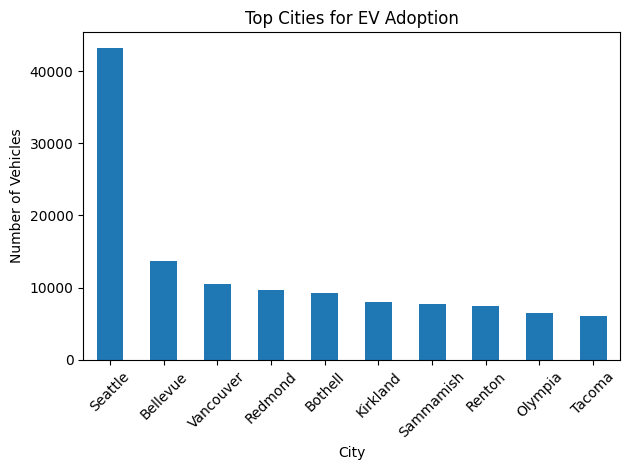

In [77]:
city_counts = df['city'].value_counts().head(10)

plt.figure()
city_counts.plot(kind='bar')
plt.title("Top Cities for EV Adoption")
plt.xlabel("City")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../visuals/charts/top_cities.png")
plt.show()

## EV Type Distribution
This shows the proportion of Battery Electric Vehicles vs Plug-in Hybrid Vehicles.

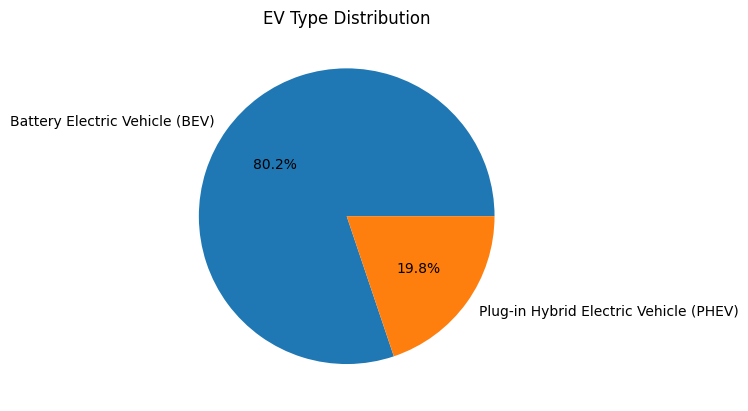

In [75]:
type_counts = df['electric vehicle type'].value_counts()

plt.figure()
type_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("EV Type Distribution")
plt.ylabel("")
plt.savefig("../visuals/charts/ev_type.png")
plt.show()

## Key Insights

- EV adoption has increased rapidly after 2020, indicating strong market growth.
- Tesla dominates the EV market with a significant lead over other manufacturers.
- Since the dataset focuses on Washington State, geographic analysis shows EV adoption is concentrated in specific counties and cities.
- Battery Electric Vehicles (BEVs) are more common than Plug-in Hybrid Electric Vehicles (PHEVs).
- Urban areas have higher EV adoption compared to smaller cities, suggesting infrastructure and population density influence adoption.